# GRAPH EXPLORATION



In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx

In [8]:
DATA_DIR="/content/drive/MyDrive/drug_repurposing/data"

In [10]:
nodes_path=f"{DATA_DIR}/hetionet-v1.0-nodes.tsv"
nodes_df=pd.read_csv(nodes_path, sep="\t")
nodes_df.head()

,id,name,kind
0,Anatomy::UBERON:0000002,uterine cervix,Anatomy
1,Anatomy::UBERON:0000004,nose,Anatomy
2,Anatomy::UBERON:0000006,islet of Langerhans,Anatomy
3,Anatomy::UBERON:0000007,pituitary gland,Anatomy
4,Anatomy::UBERON:0000010,peripheral nervous system,Anatomy


In [11]:
nodes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47031 entries, 0 to 47030
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      47031 non-null  object
 1   name    47031 non-null  object
 2   kind    47031 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


In [12]:
nodes_df["kind"].value_counts()

,count
kind,
Gene,20945
Biological Process,11381
Side Effect,5734
Molecular Function,2884
Pathway,1822
Compound,1552
Cellular Component,1391
Symptom,438
Anatomy,402


In [14]:
relevant_node_types=["Compound", "Disease","Gene"]
nodes_df[nodes_df["kind"].isin(relevant_node_types)]["kind"].value_counts()

,count
kind,
Gene,20945
Compound,1552
Disease,137


In [15]:
edges_path = f"{DATA_DIR}/edges.sif"
edges_df = pd.read_csv(edges_path, sep="\t", header=None, names=["source", "relation", "target"])
edges_df.head()

,source,relation,target
0,source,metaedge,target
1,Gene::9021,GpBP,Biological Process::GO:0071357
2,Gene::51676,GpBP,Biological Process::GO:0098780
3,Gene::19,GpBP,Biological Process::GO:0055088
4,Gene::3176,GpBP,Biological Process::GO:0010243


In [16]:
#dropping row 0 - repeat of header
edges_df = edges_df.iloc[1:].reset_index(drop=True)
edges_df.head()

,source,relation,target
0,Gene::9021,GpBP,Biological Process::GO:0071357
1,Gene::51676,GpBP,Biological Process::GO:0098780
2,Gene::19,GpBP,Biological Process::GO:0055088
3,Gene::3176,GpBP,Biological Process::GO:0010243
4,Gene::3039,GpBP,Biological Process::GO:0006898


In [17]:
print("total edges:", len(edges_df))
edges_df["relation"].value_counts().head(15)

total edges: 2250197


,count
relation,
GpBP,559504
AeG,526407
Gr>G,265672
GiG,147164
CcSE,138944
AdG,102240
AuG,97848
GpMF,97222
GpPW,84372


In [19]:
edges_df["relation"].value_counts().head(30)

,count
relation,
GpBP,559504
AeG,526407
Gr>G,265672
GiG,147164
CcSE,138944
AdG,102240
AuG,97848
GpMF,97222
GpPW,84372


In [20]:
edges_df.sample(10)

,source,relation,target
1181270,Gene::10542,GpCC,Cellular Component::GO:0005764
676945,Gene::3106,GiG,Gene::10537
807933,Anatomy::UBERON:0000178,AdG,Gene::5994
1356273,Gene::4089,Gr>G,Gene::5018
588429,Gene::5833,GiG,Gene::9869
372605,Gene::7056,GpBP,Biological Process::GO:0010243
1571174,Gene::55690,GpPW,Pathway::PC7_8234
785177,Anatomy::UBERON:0001296,AdG,Gene::378925
521626,Gene::2865,GpBP,Biological Process::GO:0002879
488419,Gene::8837,GpBP,Biological Process::GO:0045861


In [21]:
compound_edges = edges_df[edges_df["source"].str.startswith("Compound") | edges_df["target"].str.startswith("Compound")]
compound_edges["relation"].value_counts().head(20)

,count
relation,
CcSE,138944
CdG,21102
CuG,18756
CbG,11571
CrC,6486
PCiC,1029
CtD,755
CpD,390


In [22]:
disease_edges = edges_df[edges_df["source"].str.startswith("Disease") | edges_df["target"].str.startswith("Disease")]
disease_edges["relation"].value_counts()

,count
relation,
DaG,12623
DuG,7731
DdG,7623
DlA,3602
DpS,3357
CtD,755
DrD,543
CpD,390


In [23]:
#confirming ctd edges
compound_disease_edges = edges_df[edges_df["source"].str.startswith("Compound") & edges_df["target"].str.startswith("Disease")]
compound_disease_edges.head()

,source,relation,target
727736,Compound::DB00997,CtD,Disease::DOID:363
727737,Compound::DB00206,CtD,Disease::DOID:10763
727738,Compound::DB00960,CtD,Disease::DOID:10763
727739,Compound::DB00665,CtD,Disease::DOID:10283
727740,Compound::DB00290,CtD,Disease::DOID:2998


In [24]:
compound_disease_edges["relation"].value_counts()

,count
relation,
CtD,755
CpD,390


In [25]:
compound_disease_edges.sample(5)

,source,relation,target
728046,Compound::DB00800,CtD,Disease::DOID:10763
772050,Compound::DB00514,CpD,Disease::DOID:2377
772162,Compound::DB00734,CpD,Disease::DOID:3312
728322,Compound::DB00987,CtD,Disease::DOID:0060073
728324,Compound::DB00014,CtD,Disease::DOID:1612


The CtD metaedge represents known therapeutic relationships where a compound is used to treat a disease. This relation is used as the positive class for link prediction.

In [26]:
print("CtD edges:", len(compound_disease_edges))

CtD edges: 1145


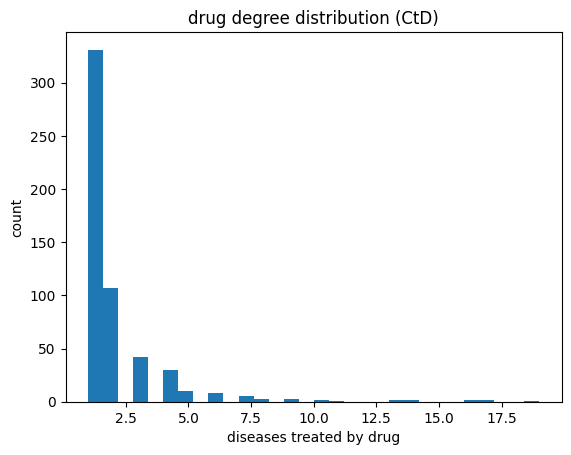

In [30]:
from collections import Counter

drug_degree = Counter(compound_disease_edges["source"])

plt.figure()
plt.hist(drug_degree.values(), bins=30)
plt.xlabel("diseases treated by drug")
plt.ylabel("count")
plt.title("drug degree distribution (CtD)")
plt.show()

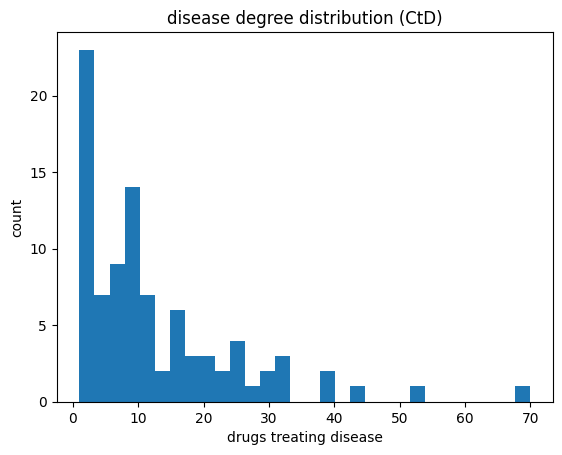

In [29]:
disease_degree = Counter(compound_disease_edges["target"])

plt.figure()
plt.hist(disease_degree.values(), bins=30)
plt.xlabel("drugs treating disease")
plt.ylabel("count")
plt.title("disease degree distribution (CtD)")
plt.show()

In [31]:
import random

In [43]:
#name of node
id_to_name = dict(zip(nodes_df["id"], nodes_df["name"]))

In [34]:
#random drug with degree >=3
candidate_drugs=[d for d, deg in drug_degree.items() if deg >= 3]
drug_id=random.choice(candidate_drugs)
drug_id

'Compound::DB01104'

In [35]:
#local neighbourhood - checking diseases treated by this
connected_diseases=compound_disease_edges[compound_disease_edges["source"] == drug_id]["target"].tolist()
connected_diseases

['Disease::DOID:5419',
 'Disease::DOID:12849',
 'Disease::DOID:594',
 'Disease::DOID:1595']

In [37]:
#biological context
compound_gene_edges = edges_df[
    (edges_df["source"] == drug_id) &
    (edges_df["relation"].str.startswith("C")) &
    (edges_df["target"].str.startswith("Gene"))
]

genes=compound_gene_edges["target"].tolist()[:5]  # limit to 5 genes
genes

['Gene::4129', 'Gene::6531', 'Gene::4128', 'Gene::1559', 'Gene::1544']

In [44]:
G = nx.Graph()

G.add_node(
    drug_id,
    node_type="Compound",
    label=id_to_name.get(drug_id, drug_id)
)

for disease in connected_diseases:
    G.add_node(
        disease,
        node_type="Disease",
        label=id_to_name.get(disease, disease)
    )
    G.add_edge(drug_id, disease, relation="CtD")

for gene in genes:
    G.add_node(
        gene,
        node_type="Gene",
        label=id_to_name.get(gene, gene)
    )
    G.add_edge(drug_id, gene, relation="CdG")

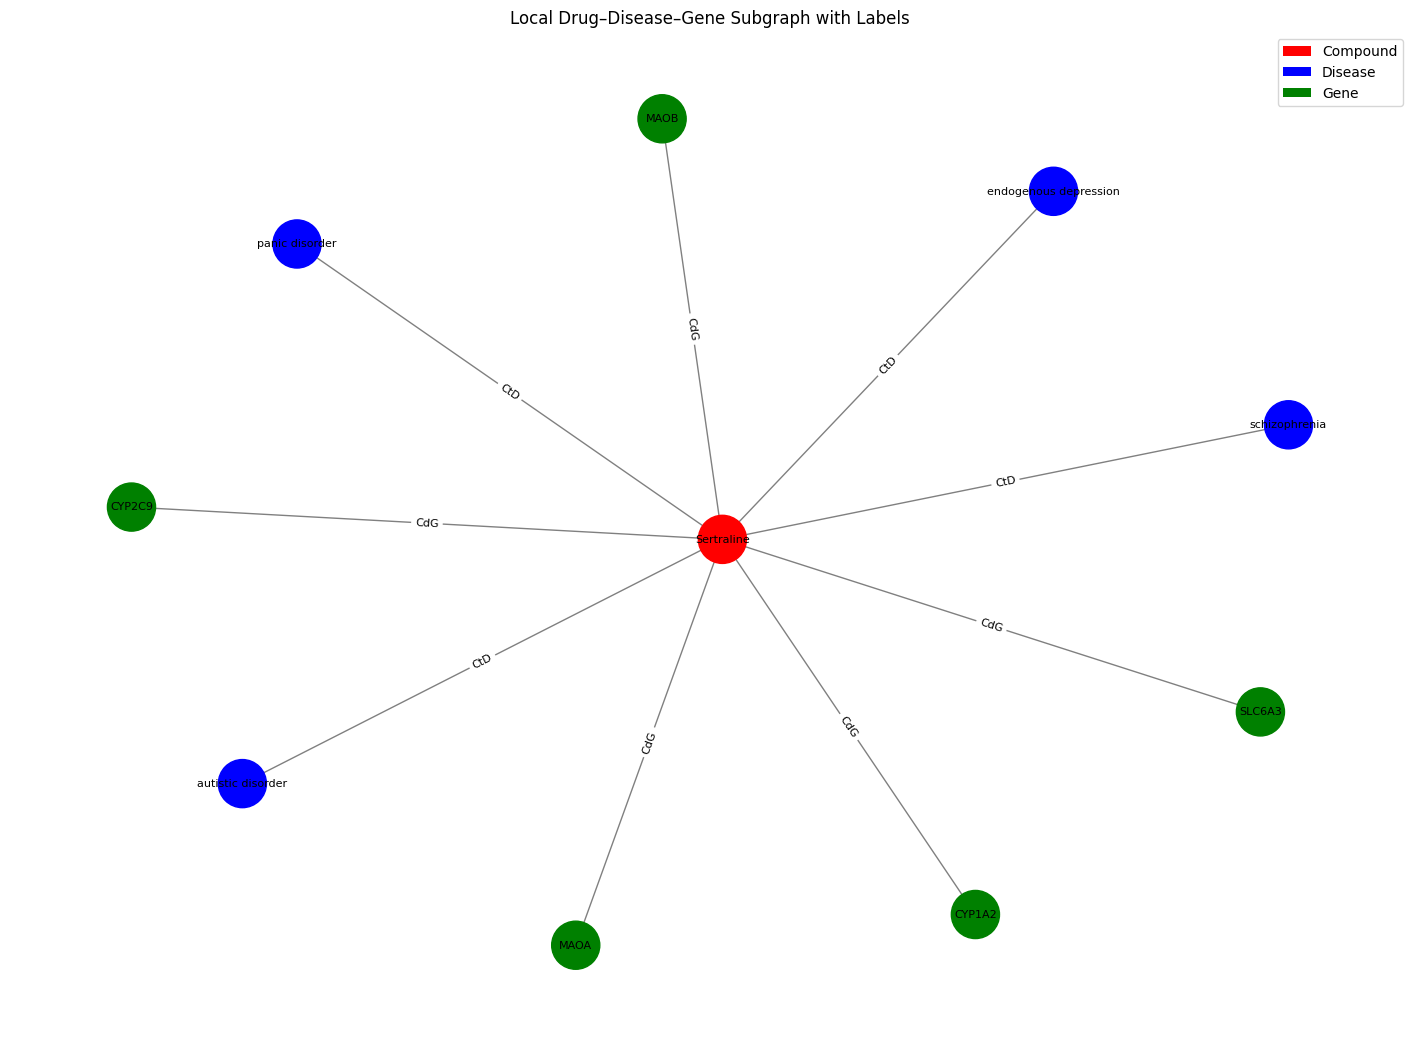

In [45]:
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42)

node_colors = []
for node in G.nodes():
    ntype = G.nodes[node]["node_type"]
    if ntype == "Compound":
        node_colors.append("red")
    elif ntype == "Disease":
        node_colors.append("blue")
    else:
        node_colors.append("green")

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=1200,
    edge_color="gray",
    with_labels=False
)

node_labels = {
    node: G.nodes[node]["label"]
    for node in G.nodes()
}
nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=8
)

edge_labels = {
    (u, v): G.edges[u, v]["relation"]
    for u, v in G.edges()
}
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Compound'),
    Patch(facecolor='blue', label='Disease'),
    Patch(facecolor='green', label='Gene')
]
plt.legend(handles=legend_elements, loc="best")

plt.title("Local Drug–Disease–Gene Subgraph with Labels")
plt.axis("off")
plt.show()